In [2]:
import sys
sys.path.append('../src')
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

with h5py.File('../data/processed/injected_v1/injected_dataset.h5', 'r') as f:
    images = f['images'][:]
    residuals = f['residuals'][:]

metadata = pd.read_parquet('../data/processed/injected_v1/injected_dataset_metadata.parquet')
labels = metadata['label'].values

print(images.shape, labels.shape)
print(pd.Series(labels).value_counts())

(3988, 120, 120) (3988,)
0    1995
1    1993
Name: count, dtype: int64


In [3]:
indices = np.arange(len(images))

train_idx, temp_idx = train_test_split(indices, test_size=0.3, stratify=labels, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=labels[temp_idx], random_state=42)

print(f"Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}")
print("Train label balance:", pd.Series(labels[train_idx]).value_counts(normalize=True))
print("Val label balance:", pd.Series(labels[val_idx]).value_counts(normalize=True))
print("Test label balance:", pd.Series(labels[test_idx]).value_counts(normalize=True))

Train: 2791, Val: 598, Test: 599
Train label balance: 0    0.500179
1    0.499821
Name: proportion, dtype: float64
Val label balance: 1    0.5
0    0.5
Name: proportion, dtype: float64
Test label balance: 0    0.500835
1    0.499165
Name: proportion, dtype: float64


In [4]:
import torch
from torch.utils.data import Dataset, DataLoader

class LensDataset(Dataset):
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = torch.from_numpy(self.images[idx]).float().unsqueeze(0)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return image, label


train_dataset = LensDataset(images[train_idx], labels[train_idx])
val_dataset = LensDataset(images[val_idx], labels[val_idx])
test_dataset = LensDataset(images[test_idx], labels[test_idx])

sample_image, sample_label = train_dataset[0]
print(sample_image.shape, sample_image.dtype, sample_label)

torch.Size([1, 120, 120]) torch.float32 tensor(0)


In [5]:
import torch.nn as nn
from torchvision.models import resnet18

model = resnet18(weights=None, num_classes=2)

model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(device)

test_input = sample_image.unsqueeze(0).to(device)
test_output = model(test_input)
print(test_output.shape)

cuda
torch.Size([1, 2])


In [6]:
from torch.utils.data import DataLoader
import torch.optim as optim

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print(len(train_loader), len(val_loader), len(test_loader))

88 19 19


In [7]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images_batch, labels_batch in loader:
        images_batch, labels_batch = images_batch.to(device), labels_batch.to(device)

        optimizer.zero_grad()
        outputs = model(images_batch)
        loss = criterion(outputs, labels_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images_batch.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels_batch).sum().item()
        total += labels_batch.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images_batch, labels_batch in loader:
            images_batch, labels_batch = images_batch.to(device), labels_batch.to(device)
            outputs = model(images_batch)
            loss = criterion(outputs, labels_batch)

            total_loss += loss.item() * images_batch.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels_batch).sum().item()
            total += labels_batch.size(0)

    return total_loss / total, correct / total

In [8]:
n_epochs = 15

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(n_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{n_epochs} - train_loss: {train_loss:.4f}, train_acc: {train_acc:.4f}, "
          f"val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}")

Epoch 1/15 - train_loss: 0.4229, train_acc: 0.7983, val_loss: 3.6579, val_acc: 0.5151
Epoch 2/15 - train_loss: 0.2760, train_acc: 0.8785, val_loss: 1.4772, val_acc: 0.6806
Epoch 3/15 - train_loss: 0.2543, train_acc: 0.8982, val_loss: 4.2136, val_acc: 0.6522
Epoch 4/15 - train_loss: 0.1833, train_acc: 0.9265, val_loss: 1.4605, val_acc: 0.5368
Epoch 5/15 - train_loss: 0.2377, train_acc: 0.9065, val_loss: 0.1787, val_acc: 0.9431
Epoch 6/15 - train_loss: 0.1646, train_acc: 0.9334, val_loss: 0.5345, val_acc: 0.8880
Epoch 7/15 - train_loss: 0.1314, train_acc: 0.9523, val_loss: 0.1733, val_acc: 0.9482
Epoch 8/15 - train_loss: 0.1456, train_acc: 0.9412, val_loss: 1.0327, val_acc: 0.5903
Epoch 9/15 - train_loss: 0.0991, train_acc: 0.9652, val_loss: 0.4575, val_acc: 0.9047
Epoch 10/15 - train_loss: 0.1062, train_acc: 0.9592, val_loss: 1.6069, val_acc: 0.5552
Epoch 11/15 - train_loss: 0.1269, train_acc: 0.9520, val_loss: 0.1439, val_acc: 0.9632
Epoch 12/15 - train_loss: 0.1084, train_acc: 0.9566,

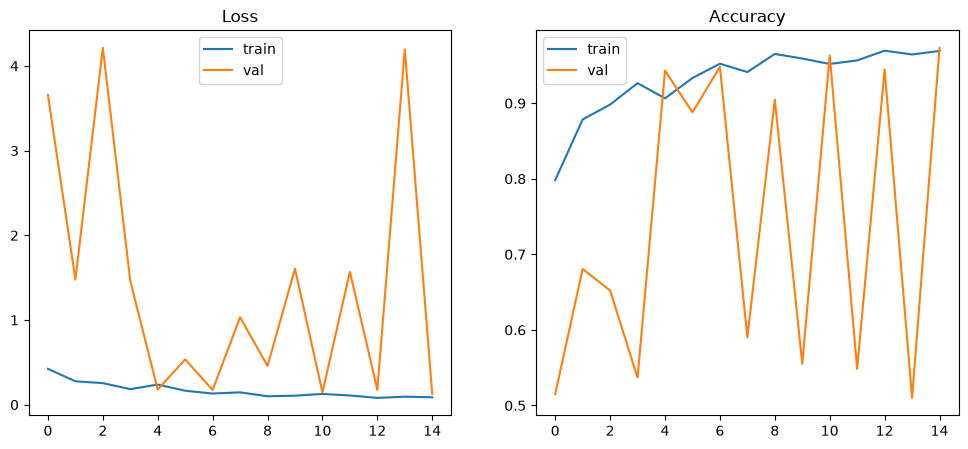

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(history['train_loss'], label='train')
axes[0].plot(history['val_loss'], label='val')
axes[0].set_title('Loss')
axes[0].legend()
axes[1].plot(history['train_acc'], label='train')
axes[1].plot(history['val_acc'], label='val')
axes[1].set_title('Accuracy')
axes[1].legend()
plt.show()

In [10]:
model = resnet18(weights=None, num_classes=2)
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-4)

def train_one_epoch_clipped(model, loader, criterion, optimizer, device, max_grad_norm=1.0):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images_batch, labels_batch in loader:
        images_batch, labels_batch = images_batch.to(device), labels_batch.to(device)

        optimizer.zero_grad()
        outputs = model(images_batch)
        loss = criterion(outputs, labels_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()

        total_loss += loss.item() * images_batch.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels_batch).sum().item()
        total += labels_batch.size(0)

    return total_loss / total, correct / total


history_v2 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(n_epochs):
    train_loss, train_acc = train_one_epoch_clipped(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history_v2['train_loss'].append(train_loss)
    history_v2['train_acc'].append(train_acc)
    history_v2['val_loss'].append(val_loss)
    history_v2['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{n_epochs} - train_loss: {train_loss:.4f}, train_acc: {train_acc:.4f}, "
          f"val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}")

Epoch 1/15 - train_loss: 0.3851, train_acc: 0.8180, val_loss: 0.4787, val_acc: 0.8311
Epoch 2/15 - train_loss: 0.2381, train_acc: 0.9036, val_loss: 3.3941, val_acc: 0.5000
Epoch 3/15 - train_loss: 0.2346, train_acc: 0.9036, val_loss: 0.6695, val_acc: 0.6204
Epoch 4/15 - train_loss: 0.1717, train_acc: 0.9305, val_loss: 1.1765, val_acc: 0.6037
Epoch 5/15 - train_loss: 0.1430, train_acc: 0.9477, val_loss: 0.4426, val_acc: 0.9114
Epoch 6/15 - train_loss: 0.1544, train_acc: 0.9380, val_loss: 0.1933, val_acc: 0.9331
Epoch 7/15 - train_loss: 0.1296, train_acc: 0.9563, val_loss: 0.3767, val_acc: 0.9247
Epoch 8/15 - train_loss: 0.1189, train_acc: 0.9609, val_loss: 1.7009, val_acc: 0.5769
Epoch 9/15 - train_loss: 0.1114, train_acc: 0.9588, val_loss: 0.8591, val_acc: 0.7525
Epoch 10/15 - train_loss: 0.1105, train_acc: 0.9581, val_loss: 0.1309, val_acc: 0.9615
Epoch 11/15 - train_loss: 0.1142, train_acc: 0.9620, val_loss: 2.2906, val_acc: 0.5786
Epoch 12/15 - train_loss: 0.1207, train_acc: 0.9620,

In [11]:
def evaluate_per_batch(model, loader, criterion, device):
    model.eval()
    batch_accs = []
    with torch.no_grad():
        for images_batch, labels_batch in loader:
            images_batch, labels_batch = images_batch.to(device), labels_batch.to(device)
            outputs = model(images_batch)
            _, predicted = torch.max(outputs, 1)
            acc = (predicted == labels_batch).float().mean().item()
            batch_accs.append(acc)
    return batch_accs

batch_accs = evaluate_per_batch(model, val_loader, criterion, device)
print(batch_accs)

[0.6875, 0.59375, 0.65625, 0.53125, 0.59375, 0.5, 0.6875, 0.625, 0.625, 0.6875, 0.5625, 0.59375, 0.40625, 0.625, 0.375, 0.5625, 0.59375, 0.65625, 0.4545454680919647]


In [12]:
def convert_bn_to_gn(module, num_groups=8):
    for name, child in module.named_children():
        if isinstance(child, nn.BatchNorm2d):
            num_channels = child.num_features
            setattr(module, name, nn.GroupNorm(num_groups=min(num_groups, num_channels), num_channels=num_channels))
        else:
            convert_bn_to_gn(child, num_groups)

model = resnet18(weights=None, num_classes=2)
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
convert_bn_to_gn(model)
model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-4)

history_v3 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(n_epochs):
    train_loss, train_acc = train_one_epoch_clipped(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history_v3['train_loss'].append(train_loss)
    history_v3['train_acc'].append(train_acc)
    history_v3['val_loss'].append(val_loss)
    history_v3['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{n_epochs} - train_loss: {train_loss:.4f}, train_acc: {train_acc:.4f}, "
          f"val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}")

Epoch 1/15 - train_loss: 0.6096, train_acc: 0.6768, val_loss: 0.5675, val_acc: 0.7090
Epoch 2/15 - train_loss: 0.4645, train_acc: 0.7764, val_loss: 0.5019, val_acc: 0.8161
Epoch 3/15 - train_loss: 0.3613, train_acc: 0.8509, val_loss: 0.6434, val_acc: 0.7793
Epoch 4/15 - train_loss: 0.3633, train_acc: 0.8488, val_loss: 0.2505, val_acc: 0.8880
Epoch 5/15 - train_loss: 0.2748, train_acc: 0.8918, val_loss: 0.1648, val_acc: 0.9348
Epoch 6/15 - train_loss: 0.3108, train_acc: 0.8800, val_loss: 0.4778, val_acc: 0.8729
Epoch 7/15 - train_loss: 0.2781, train_acc: 0.9090, val_loss: 0.2636, val_acc: 0.8662
Epoch 8/15 - train_loss: 0.2466, train_acc: 0.9197, val_loss: 0.1537, val_acc: 0.9465
Epoch 9/15 - train_loss: 0.2049, train_acc: 0.9176, val_loss: 0.1590, val_acc: 0.9331
Epoch 10/15 - train_loss: 0.1553, train_acc: 0.9427, val_loss: 0.2422, val_acc: 0.9398
Epoch 11/15 - train_loss: 0.2795, train_acc: 0.9036, val_loss: 0.2896, val_acc: 0.9398
Epoch 12/15 - train_loss: 0.1501, train_acc: 0.9541,

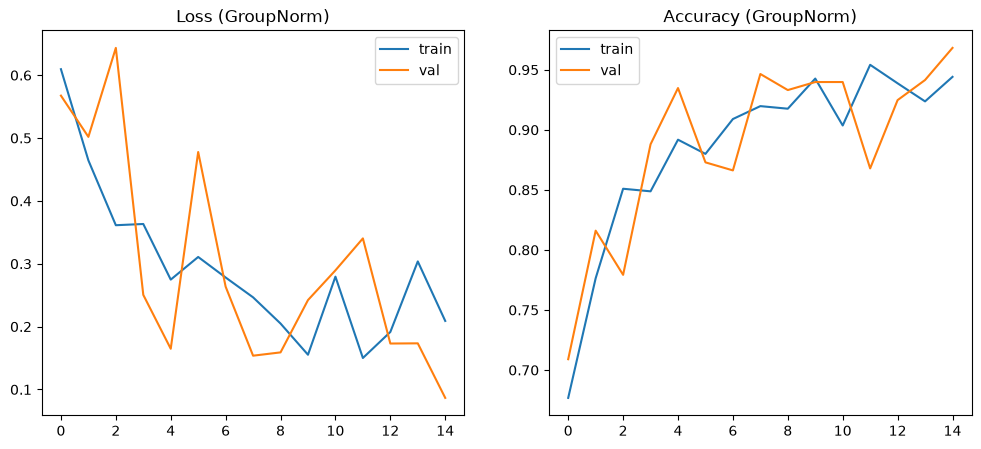

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(history_v3['train_loss'], label='train')
axes[0].plot(history_v3['val_loss'], label='val')
axes[0].set_title('Loss (GroupNorm)')
axes[0].legend()
axes[1].plot(history_v3['train_acc'], label='train')
axes[1].plot(history_v3['val_acc'], label='val')
axes[1].set_title('Accuracy (GroupNorm)')
axes[1].legend()
plt.show()

In [14]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report

model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images_batch, labels_batch in test_loader:
        images_batch = images_batch.to(device)
        outputs = model(images_batch)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels_batch.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

print(classification_report(all_labels, all_preds, target_names=['non-lens', 'lens']))
print("Confusion matrix:")
print(confusion_matrix(all_labels, all_preds))

              precision    recall  f1-score   support

    non-lens       0.95      0.97      0.96       300
        lens       0.97      0.95      0.96       299

    accuracy                           0.96       599
   macro avg       0.96      0.96      0.96       599
weighted avg       0.96      0.96      0.96       599

Confusion matrix:
[[291   9]
 [ 15 284]]


False positives: 9, False negatives: 15


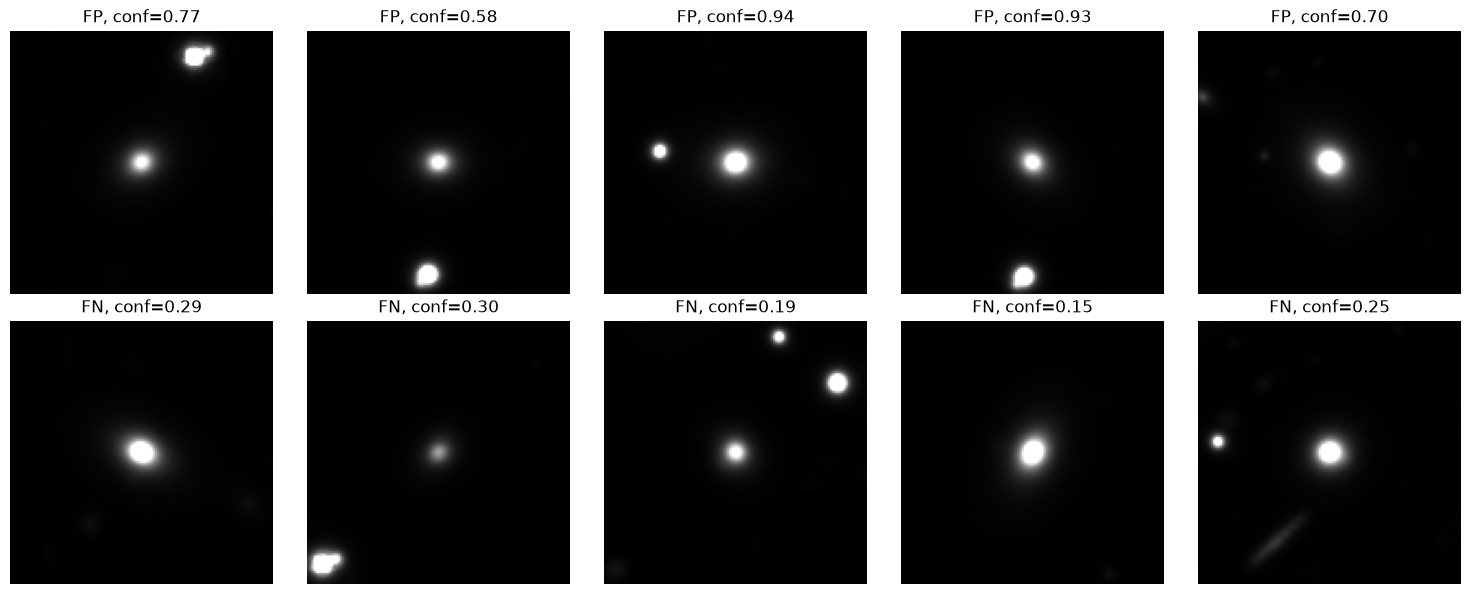

In [15]:
false_positives_idx = np.where((all_preds == 1) & (all_labels == 0))[0]
false_negatives_idx = np.where((all_preds == 0) & (all_labels == 1))[0]

print(f"False positives: {len(false_positives_idx)}, False negatives: {len(false_negatives_idx)}")

test_images_arr = images[test_idx]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(min(5, len(false_positives_idx))):
    ax = axes[0, i]
    idx = false_positives_idx[i]
    ax.imshow(test_images_arr[idx], cmap='gray', origin='lower')
    ax.set_title(f"FP, conf={all_probs[idx]:.2f}")
    ax.axis('off')
for i in range(min(5, len(false_negatives_idx))):
    ax = axes[1, i]
    idx = false_negatives_idx[i]
    ax.imshow(test_images_arr[idx], cmap='gray', origin='lower')
    ax.set_title(f"FN, conf={all_probs[idx]:.2f}")
    ax.axis('off')
plt.tight_layout()
plt.show()